In [1]:
%reload_ext autoreload
%autoreload 2

import os
from pathlib import Path

print(Path().cwd())
os.chdir(Path(os.getcwd()).parent)
print(Path().cwd())

/home/yuanshanwu/Documents/GitHub/QuantUS-Plugins-CEUS/CLI-Demos
/home/yuanshanwu/Documents/GitHub/QuantUS-Plugins-CEUS


In [2]:
from src.image_loading.options import get_scan_loaders

print("Available scan loaders:", list(get_scan_loaders().keys()))

Available scan loaders: ['mp4', 'custom_dicom', 'nifti', 'avi']


In [3]:
scan_type = 'nifti'

# Takes the DICOM file as input for contrast enhanced ultrasound (CEUS) scans
CEUS_scan_path = '/home/yuanshanwu/Documents/TUL/CEUS-Studies/P05_V02_CE01/NewInterpolation/UCSD-P05-V02-CE1_09.45.08/UCSD-P05-V02-CE1_09.45.08_mf_sip_capture_50_2_1_0_CEUS.nii'
bmode_scan_path = '/home/yuanshanwu/Documents/TUL/CEUS-Studies/P05_V02_CE01/NewInterpolation/UCSD-P05-V02-CE1_09.45.08/UCSD-P05-V02-CE1_09.45.08_mf_sip_capture_50_2_1_0_BMODE.nii'
scan_loader_kwargs = {
}

In [4]:
from src.entrypoints import scan_loading_step

image_data = scan_loading_step(scan_type, CEUS_scan_path, **scan_loader_kwargs)
bmode_image_data = scan_loading_step(scan_type, bmode_scan_path, **scan_loader_kwargs)

Using memory-mapped loading for 7.5 GB file
Using memory-mapped loading for 7.5 GB file


In [5]:
scan_type = 'nifti'

# Takes the DICOM file as input for contrast enhanced ultrasound (CEUS) scans
CEUS_scan_path_low_quality = '/media/yuanshanwu/T5 EVO/UCSD_3DCEUS/SIP/2025.08.19_P05V02/UCSD-P05-V02-CE1_09.45.08/UCSD-P05-V02-CE1_09.45.08_mf_sip_capture_50_2_1_0.raw_CEUS.nii.gz'
bmode_scan_path_low_quality = '/media/yuanshanwu/T5 EVO/UCSD_3DCEUS/SIP/2025.08.19_P05V02/UCSD-P05-V02-CE1_09.45.08/UCSD-P05-V02-CE1_09.45.08_mf_sip_capture_50_2_1_0.raw_BMODE.nii.gz'
scan_loader_kwargs = {
}

image_data_low_quality = scan_loading_step(scan_type, CEUS_scan_path_low_quality, **scan_loader_kwargs)
bmode_image_data_low_quality = scan_loading_step(scan_type, bmode_scan_path_low_quality, **scan_loader_kwargs)

# Image Quality improvement of the B mode and CEUS iamges

In [ ]:
bmode_image_data.pixel_data.shape

In [6]:
from src.postprocessing.napari_3d_ultrasound_viewer import interactive_ortho_viewer
interactive_ortho_viewer(bmode_image_data_low_quality.pixel_data[:, :, :, 300])

NameError: name 'bmode_image_data_low_quality' is not defined

In [8]:
from src.postprocessing.napari_3d_ultrasound_viewer import interactive_ortho_viewer
interactive_ortho_viewer(bmode_image_data.pixel_data[:, :, :, 300])

interactive(children=(IntSlider(value=147, description='Lateral (X):', max=294), IntSlider(value=109, descript…

Data shape: (295, 218, 219)
Use the sliders above to move the crosshairs!


In [9]:
from src.postprocessing.post_processing import enhance_image, denoise_ceus_wavelet,speckle_reduction_bias_field
import numpy as np

clahe_image = enhance_image(bmode_image_data.pixel_data[:, :, :, 300], method='clahe', clip_limit=1.0)
final_image = enhance_image(clahe_image, method='gamma', gamma=1.5)
CEUS_image = speckle_reduction_bias_field(final_image)

interactive_ortho_viewer(CEUS_image)

interactive(children=(IntSlider(value=147, description='Lateral (X):', max=294), IntSlider(value=109, descript…

Data shape: (295, 218, 219)
Use the sliders above to move the crosshairs!


# Determine the Image quality using several metrics

1. speckle SNR
2. SSIN (structural similarity metrics)
3. CNR (lesion contrast to noise ratio)

In [8]:
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt
def calculate_ctr_3d(volume_3d, contrast_voi, tissue_voi):
    """
    Calculate Contrast-to-Tissue Ratio for CEUS imaging
    
    CTR = (μ_contrast - μ_tissue) / μ_tissue
    
    Higher is better (better contrast enhancement)
    Positive = contrast region is brighter than tissue
    
    Args:
        volume_3d: 3D numpy array (Y, X, Z)
        contrast_voi: VOI for contrast-enhanced region (y1, y2, x1, x2, z1, z2)
        tissue_voi: VOI for background tissue (y1, y2, x1, x2, z1, z2)
    
    Returns:
        CTR value (float)
    
    Example:
        # Define VOIs for contrast agent and tissue
        contrast_voi = (40, 80, 50, 90, 15, 25)  # Where contrast agent is
        tissue_voi = (100, 140, 50, 90, 15, 25)   # Background tissue
        
        ctr = calculate_ctr_3d(volume, contrast_voi, tissue_voi)
        print(f"CTR: {ctr:.3f}")
    """
    # Extract contrast-enhanced region
    y1, y2, x1, x2, z1, z2 = contrast_voi
    contrast_region = volume_3d[y1:y2, x1:x2, z1:z2]
    mean_contrast = np.mean(contrast_region)
    
    # Extract tissue background region
    y1, y2, x1, x2, z1, z2 = tissue_voi
    tissue_region = volume_3d[y1:y2, x1:x2, z1:z2]
    mean_tissue = np.mean(tissue_region)
    
    if mean_tissue == 0:
        return float('inf')
    
    ctr = (mean_contrast - mean_tissue) / (mean_tissue)
    return ctr

def draw_voi_3d(volume_3d, voi_list, voi_names=None, voi_colors=None, 
                slice_indices=None, figsize=(15, 5)):
    """
    Draw rectangular VOIs on three orthogonal planes (axial, sagittal, coronal)
    
    Args:
        volume_3d: 3D numpy array with shape (depth, lateral, elevational)
        voi_list: List of VOIs, each as (d1, d2, l1, l2, e1, e2)
        voi_names: List of names for each VOI (optional)
        voi_colors: List of colors for each VOI (optional)
        slice_indices: Tuple of (depth_idx, lateral_idx, elevational_idx) for slice positions
                      If None, uses middle slices
        figsize: Figure size
    
    Returns:
        matplotlib figure
    
    Example:
        tumor_voi = (110, 125, 135, 145, 100, 120)
        tissue_voi = (155, 170, 135, 145, 100, 120)
        
        fig = draw_voi_3d(
            volume, 
            [tumor_voi, tissue_voi],
            voi_names=['Tumor', 'Tissue'],
            voi_colors=['red', 'blue']
        )
        plt.show()
    """
    
    # Ensure voi_list is a list
    if not isinstance(voi_list, list):
        voi_list = [voi_list]
    
    # Default names and colors
    if voi_names is None:
        voi_names = [f'VOI {i+1}' for i in range(len(voi_list))]
    
    if voi_colors is None:
        voi_colors = ['red', 'blue', 'green', 'yellow', 'cyan', 'magenta']
    
    # Get volume dimensions
    depth, lateral, elevational = volume_3d.shape
    
    # Default slice indices (middle of volume)
    if slice_indices is None:
        slice_indices = (depth // 2, lateral // 2, elevational // 2)
    
    depth_idx, lateral_idx, elevational_idx = slice_indices
    
    # Extract slices
    axial_slice = np.transpose(volume_3d[:, :, elevational_idx])      # (depth, lateral)
    sagittal_slice = volume_3d[:, lateral_idx, :]         # (depth, elevational)
    coronal_slice = volume_3d[depth_idx, :, :]            # (lateral, elevational)
    
    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # 1. AXIAL VIEW (depth vs lateral, looking down elevational axis)
    axes[0].imshow(axial_slice, cmap='gray', aspect='auto', origin='upper')
    axes[0].set_title(f'Axial View (Elevational = {elevational_idx})\nDepth vs Lateral')
    axes[0].set_xlabel('Lateral')
    axes[0].set_ylabel('Depth')
    
    # Draw VOIs on axial view
    for voi, name, color in zip(voi_list, voi_names, voi_colors):
        l1, l2, d1, d2, e1, e2 = voi
        
        # Check if this slice intersects the VOI in elevational direction
        if e1 <= elevational_idx <= e2:
            # Rectangle parameters: (x, y, width, height)
            # x = lateral, y = depth
            rect = Rectangle((l1, d1), l2-l1, d2-d1, 
                           linewidth=2, edgecolor=color, facecolor='none', 
                           label=name)
            axes[0].add_patch(rect)
    
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # 2. SAGITTAL VIEW (depth vs elevational, looking from side - lateral axis)
    axes[1].imshow(sagittal_slice, cmap='gray', aspect='auto', origin='upper')
    axes[1].set_title(f'Sagittal View (Lateral = {lateral_idx})\nDepth vs Elevational')
    axes[1].set_xlabel('Elevational')
    axes[1].set_ylabel('Depth')
    
    # Draw VOIs on sagittal view
    for voi, name, color in zip(voi_list, voi_names, voi_colors):
        d1, d2, l1, l2, e1, e2 = voi
        
        # Check if this slice intersects the VOI in lateral direction
        if l1 <= lateral_idx <= l2:
            # Rectangle: x = elevational, y = depth
            rect = Rectangle((e1, d1), e2-e1, d2-d1, 
                           linewidth=2, edgecolor=color, facecolor='none',
                           label=name)
            axes[1].add_patch(rect)
    
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    # 3. CORONAL VIEW (lateral vs elevational, looking from front - depth axis)
    axes[2].imshow(coronal_slice, cmap='gray', aspect='auto', origin='upper')
    axes[2].set_title(f'Coronal View (Depth = {depth_idx})\nLateral vs Elevational')
    axes[2].set_xlabel('Elevational')
    axes[2].set_ylabel('Lateral')
    
    # Draw VOIs on coronal view
    for voi, name, color in zip(voi_list, voi_names, voi_colors):
        d1, d2, l1, l2, e1, e2 = voi
        
        # Check if this slice intersects the VOI in depth direction
        if d1 <= depth_idx <= d2:
            # Rectangle: x = elevational, y = lateral
            rect = Rectangle((e1, l1), e2-e1, l2-l1, 
                           linewidth=2, edgecolor=color, facecolor='none',
                           label=name)
            axes[2].add_patch(rect)
    
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    
    plt.tight_layout()
    return fig


def draw_voi_3d_center_slices(volume_3d, voi_list, voi_names=None, voi_colors=None,
                               figsize=(15, 5)):
    """
    Draw VOIs on slices that pass through the CENTER of the first VOI
    
    This is useful to see the VOI in its entirety
    
    Args:
        Same as draw_voi_3d, but automatically centers on first VOI
    """
    
    # Calculate center of first VOI
    d1, d2, l1, l2, e1, e2 = voi_list[0]
    depth_center = (d1 + d2) // 2
    lateral_center = (l1 + l2) // 2
    elevational_center = (e1 + e2) // 2
    
    slice_indices = (depth_center, lateral_center, elevational_center)
    
    print(f"Showing slices at VOI center:")
    print(f"  Depth: {depth_center}")
    print(f"  Lateral: {lateral_center}")
    print(f"  Elevational: {elevational_center}")
    
    return draw_voi_3d(volume_3d, voi_list, voi_names, voi_colors, 
                      slice_indices, figsize)

(55, 62, 67, 72, 50, 60)
CTR_low_quality: -0.193
CTR_without_postprocess: -0.199
CTR_with_postprocess: -0.371
Showing slices at VOI center:
  Depth: 117
  Lateral: 140
  Elevational: 110


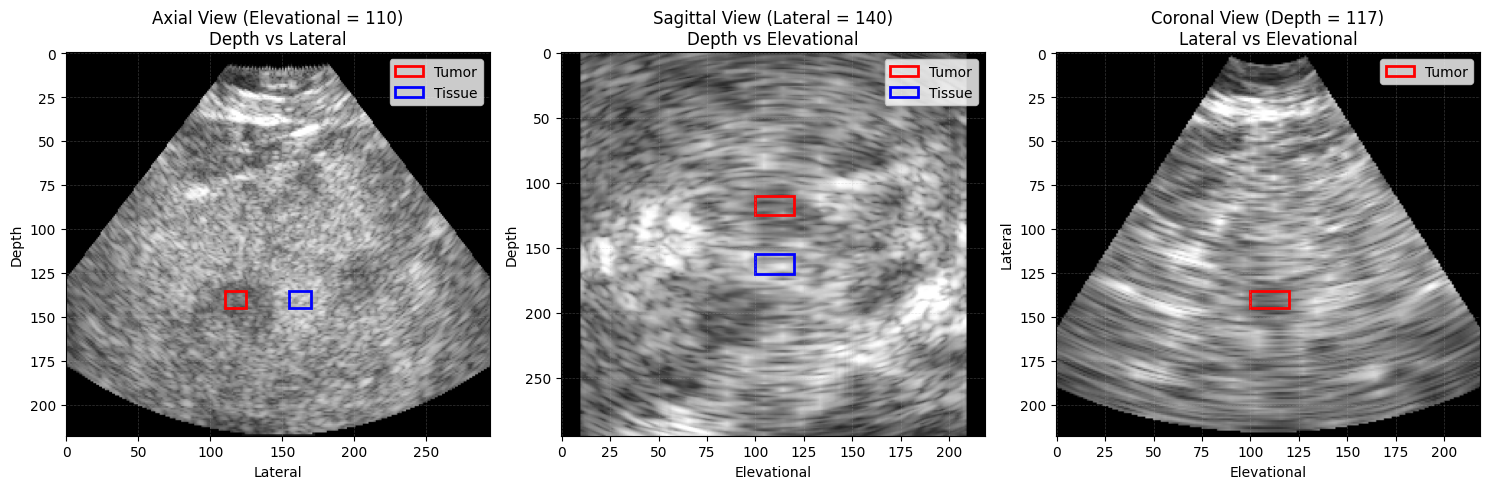

In [10]:
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import mean_squared_error as mse

img_noise = bmode_image_data_low_quality.pixel_data[:, :, :, 300]
img_high_quality = bmode_image_data.pixel_data[:, :, :, 300]
img_high_quality_postprocess = CEUS_image

# depth, lateral, elevational
tumor_voi = (110, 125, 135, 145, 100, 120)  
tissue_voi = (155, 170, 135, 145, 100, 120)   

# Low quaility voi
low_quality_tumor_voi = tuple([int(np.floor(x/2)) for x in tumor_voi])
low_quality_tissue_voi = tuple([int(np.floor(x/2)) for x in tissue_voi])

print(low_quality_tumor_voi)

ctr_low = calculate_ctr_3d(img_noise, low_quality_tumor_voi, low_quality_tissue_voi)
print(f"CTR_low_quality: {ctr_low:.3f}")
ctr_wo = calculate_ctr_3d(img_high_quality, tumor_voi, tissue_voi)
print(f"CTR_without_postprocess: {ctr_wo:.3f}")
ctr_pp = calculate_ctr_3d(img_high_quality_postprocess, tumor_voi, tissue_voi)
print(f"CTR_with_postprocess: {ctr_pp:.3f}")

fig = draw_voi_3d_center_slices(
    img_high_quality_postprocess,
    [tumor_voi, tissue_voi],
    voi_names=['Tumor', 'Tissue'],
    voi_colors=['red', 'blue']
)
plt.show()

(55, 62, 67, 72, 50, 60)
CTR_low_quality: -0.409
CTR_without_postprocess: -0.431
CTR_with_postprocess: -0.565
Showing slices at VOI center:
  Depth: 117
  Lateral: 140
  Elevational: 110


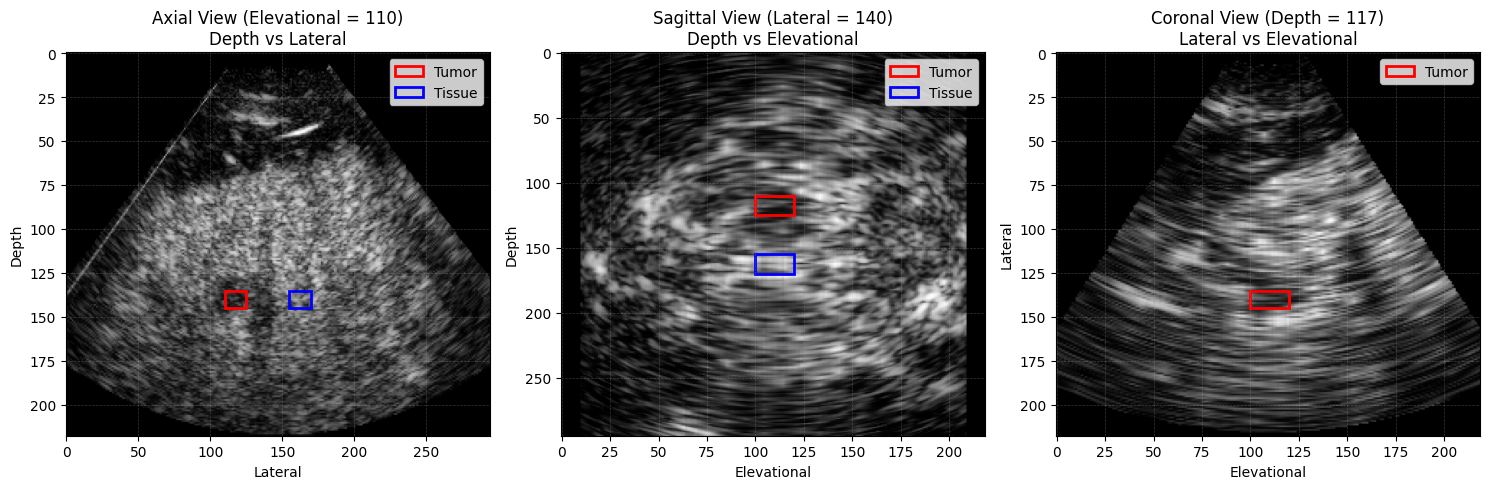

In [11]:
img_noise = image_data_low_quality.pixel_data[:, :, :, 300]
img_high_quality = image_data.pixel_data[:, :, :, 300]

clahe_image_2 = enhance_image(img_high_quality, method='clahe', clip_limit=1.0)
final_image_2 = enhance_image(clahe_image_2, method='gamma', gamma=1.5)
CEUS_image_2 = speckle_reduction_bias_field(final_image_2)

img_high_quality_postprocess = CEUS_image_2

# depth, lateral, elevational
tumor_voi = (110, 125, 135, 145, 100, 120)  
tissue_voi = (155, 170, 135, 145, 100, 120)   

# Low quaility voi
low_quality_tumor_voi = tuple([int(np.floor(x/2)) for x in tumor_voi])
low_quality_tissue_voi = tuple([int(np.floor(x/2)) for x in tissue_voi])

print(low_quality_tumor_voi)

ctr_low = calculate_ctr_3d(img_noise, low_quality_tumor_voi, low_quality_tissue_voi)
print(f"CTR_low_quality: {ctr_low:.3f}")
ctr_wo = calculate_ctr_3d(img_high_quality, tumor_voi, tissue_voi)
print(f"CTR_without_postprocess: {ctr_wo:.3f}")
ctr_pp = calculate_ctr_3d(img_high_quality_postprocess, tumor_voi, tissue_voi)
print(f"CTR_with_postprocess: {ctr_pp:.3f}")


fig = draw_voi_3d_center_slices(
    img_high_quality_postprocess,
    [tumor_voi, tissue_voi],
    voi_names=['Tumor', 'Tissue'],
    voi_colors=['red', 'blue']
)
plt.show()

# Image Tuner

In [ ]:
from src.postprocessing.post_processing import PyramidTunerGUI,image_tuner
# In Jupyter cell 1:
%gui qt
import sys
from PyQt6.QtWidgets import QApplication

# Initialize QApplication if needed
app = QApplication.instance()
if app is None:
    app = QApplication(sys.argv)
# image_tuner = PyramidTunerGUI(image_data.pixel_data[:, :, :, 300])
enhanced = image_tuner(image_data.pixel_data[:, :, :, 300])

In [ ]:
%matplotlib inline

interactive_ortho_viewer(CEUS_image)

# Demo the CEUS Video

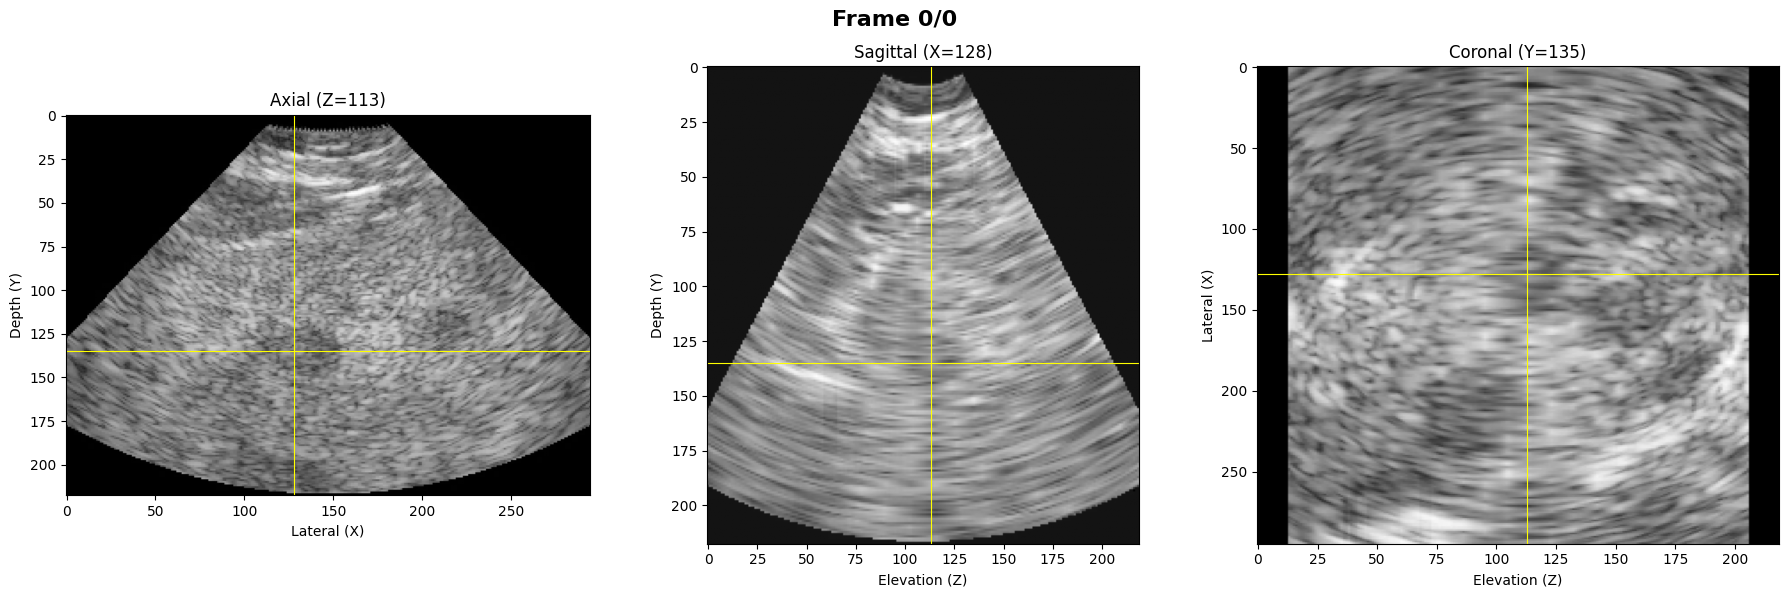

Creating GIF frames: 100%|██████████| 1/1 [00:00<00:00,  1.07it/s]

Frame 0/0


In [16]:
# Use inline backend - MORE RELIABLE for Jupyter
%matplotlib inline
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import binary_erosion
import imageio
from PIL import Image
import io
from tqdm import tqdm

print(f"Image shape: {bmode_image_data.pixel_data.shape}")

# Define slice positions
lateral_slice = 128   # X dimension
depth_slice = 135     # Y dimension  
elevation_slice = 113 # Z dimension

# Frame range
num_frames = bmode_image_data.pixel_data.shape[3]
start_frame = 0
end_frame =  1 #num_frames

print(f"Visualizing frames {start_frame} to {end_frame}")
print("Starting animation...\n")

frames = []

# Loop through frames
for frame in tqdm(range(start_frame, end_frame), desc="Creating GIF frames"):
    # Clear previous output and display current frame
    clear_output(wait=True)
    
    # Enhance image
    clahe_image = enhance_image(bmode_image_data.pixel_data[:, :, :, frame], method='clahe', clip_limit=1.0)
    final_image = enhance_image(clahe_image, method='gamma', gamma=1.2)
    CEUS_image = denoise_ceus_wavelet(final_image)
    
    # Create figure for this frame
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Calculate aspect ratios based on pixel dimensions
    # Aspect = (dimension_along_x_axis) / (dimension_along_y_axis)
    
    # Axial: x-axis is lateral (pixdim[0]), y-axis is depth (pixdim[1])
    aspect_axial = (bmode_image_data.pixdim[0]) / (bmode_image_data.pixdim[1]) if bmode_image_data.pixdim[0] != 0 else 1
    aspect_axial = aspect_axial * 1.8  # Scaling factor from original
    
    # Sagittal: x-axis is elevation (pixdim[2]), y-axis is depth (pixdim[1])
    aspect_sagittal = (bmode_image_data.pixdim[2]) / (bmode_image_data.pixdim[1]) if bmode_image_data.pixdim[2] != 0 else 1
    aspect_sagittal = aspect_sagittal * 1.5  # Scaling factor from original
    
    # Coronal: x-axis is elevation (pixdim[2]), y-axis is lateral (pixdim[0])
    aspect_coronal = (bmode_image_data.pixdim[2]) / (bmode_image_data.pixdim[0]) if bmode_image_data.pixdim[2] != 0 else 1
    aspect_coronal = aspect_coronal * 0.5  # Scaling factor from original
    
    # === AXIAL VIEW (X-Y plane at fixed Z) ===
    # Looking down from above - shows lateral (X) vs depth (Y)
    # Based on original: plane_ix=0, dims (0,1), needs transpose
    axial_img = np.transpose(CEUS_image[:, :, elevation_slice])
    axes[0].imshow(axial_img, cmap='gray', aspect=float(aspect_axial))
    axes[0].set_title(f'Axial (Z={elevation_slice})')
    axes[0].set_xlabel('Lateral (X)')
    axes[0].set_ylabel('Depth (Y)')
    axes[0].axvline(x=lateral_slice, color='yellow', lw=0.8)
    axes[0].axhline(y=depth_slice, color='yellow', lw=0.8)
    
    # === SAGITTAL VIEW (Z-Y plane at fixed X) ===
    # Looking from the side - shows elevation (Z) vs depth (Y)
    # Based on original: plane_ix=1, dims (2,1), NO transpose needed
    sagittal_img = CEUS_image[lateral_slice, :, :]
    axes[1].imshow(sagittal_img, cmap='gray', aspect=float(aspect_sagittal))
    axes[1].set_title(f'Sagittal (X={lateral_slice})')
    axes[1].set_xlabel('Elevation (Z)')
    axes[1].set_ylabel('Depth (Y)')
    axes[1].axvline(x=elevation_slice, color='yellow', lw=0.8)
    axes[1].axhline(y=depth_slice, color='yellow', lw=0.8)
    
    # === CORONAL VIEW (Z-X plane at fixed Y) ===
    # Looking from front/back - shows elevation (Z) vs lateral (X)
    # Based on original: plane_ix=2, dims (2,0), NO transpose needed
    coronal_img = CEUS_image[:, depth_slice, :]
    axes[2].imshow(coronal_img, cmap='gray', aspect=float(aspect_coronal))
    axes[2].set_title(f'Coronal (Y={depth_slice})')
    axes[2].set_xlabel('Elevation (Z)')
    axes[2].set_ylabel('Lateral (X)')
    axes[2].axvline(x=elevation_slice, color='yellow', lw=0.8)
    axes[2].axhline(y=lateral_slice, color='yellow', lw=0.8)
    
    # Add overall frame counter
    fig.suptitle(f'Frame {frame}/{end_frame-1}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Convert figure to image array (COMPATIBLE METHOD)
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=100)
    buf.seek(0)
    img = Image.open(buf).convert('RGB')
    frames.append(np.array(img))
    buf.close()
    
    # Print progress
    print(f"Frame {frame}/{end_frame-1}")
    
    # Close figure to save memory
    plt.close(fig)

In [ ]:
# Save as MP4
output_filename = '/home/yuanshanwu/Documents/GitHub/QuantUS-Plugins-CEUS/Bmode_P05_02_CE1_High_Interpolate.mp4'
imageio.mimsave(output_filename, frames, fps=10, format='FFMPEG', codec='libx264',quality=10)
print(f"Video saved to: {output_filename}")